# Phase 1 - Exploratory Data Analysis (EDA)  
### Facial Emotion Recognition Dataset (FER2013)

In this phase, we perform Exploratory Data Analysis (EDA) on the FER2013 dataset to better understand the data before building the model. The objective is to examine the dataset structure, identify potential challenges, and extract useful insights that may influence preprocessing and training decisions.

The analysis includes inspecting the dataset organization, visualizing emotion samples, analyzing class distributions, calculating image statistics, and examining image properties such as dimensions and pixel characteristics.

The findings from this phase help identify issues such as class imbalance and data variability, allowing more informed decisions for the preprocessing pipeline and model training stages in later phases.

## 1. Imports and Visualization Setup

This section imports the main libraries needed for exploratory data analysis. The imported tools are used for file handling, image loading, numerical analysis, progress tracking, and visualizing dataset statistics. The cell also configures Matplotlib settings to make the generated plots clearer and more consistent throughout the notebook. Warnings are hidden to keep the notebook output clean.

In [1]:
import os
import random
import warnings
from collections import defaultdict
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
from PIL import Image
from tqdm.notebook import tqdm

warnings.filterwarnings("ignore")
%matplotlib inline
plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})
print("✓ Imports OK")


✓ Imports OK


## 2. Dataset Configuration and Initialization

This section defines the main dataset settings and initialization parameters used throughout the EDA phase. The dataset path, emotion classes, dataset splits, visualization colors, sampling settings, and random seed values are configured here. The code also creates an output directory for saving generated figures and analysis results. Finally, a validation step ensures that the dataset path exists before continuing the analysis process.

In [2]:
# ── Set your dataset root here ───────────────────────────────────────────────
DATASET_ROOT = Path("/path/to/your/dataset")   # <-- change this

EMOTIONS = ["angry", "disgust", "fear", "happy", "neutral", "sad", "surprise"]
SPLITS   = ["train", "val", "test"]

PALETTE = {
    "angry":    "#E24B4A",
    "disgust":  "#639922",
    "fear":     "#7F77DD",
    "happy":    "#EF9F27",
    "neutral":  "#888780",
    "sad":      "#378ADD",
    "surprise": "#D4537E",
}

PIXEL_SAMPLE = 300   # images sampled per class for pixel stats
SIZE_SAMPLE  = 200   # images sampled per class for size analysis
SEED         = 42

random.seed(SEED)
np.random.seed(SEED)

OUTPUT_DIR = Path("eda_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

DATASET_ROOT = Path("/home/zainaandalhaq/Facial/fer2013_img")

assert DATASET_ROOT.exists(), f"Dataset root not found: {DATASET_ROOT}"

print(f"✓ Dataset root : {DATASET_ROOT.resolve()}")
print(f"✓ Output dir   : {OUTPUT_DIR.resolve()}")

✓ Dataset root : /home/zainaandalhaq/Facial/fer2013_img
✓ Output dir   : /home/zainaandalhaq/Facial/eda_outputs


## 3. Helper Functions

This section defines helper functions used throughout the EDA process. These functions simplify repetitive operations such as collecting image paths, loading images, and calculating dataset statistics. The functions organize the dataset structure by grouping images according to dataset splits and emotion classes, convert images into RGB format for consistent processing, and calculate sample counts for each category. Using helper functions improves code readability, reduces repetition, and makes the analysis workflow easier to maintain.

In [3]:
def collect_paths(data_root: Path) -> dict:
    """Returns paths[split][emotion] = [list of Path objects]."""
    paths = defaultdict(lambda: defaultdict(list))
    for split in SPLITS:
        split_dir = data_root / split
        if not split_dir.exists():
            continue
        for emotion in EMOTIONS:
            emotion_dir = split_dir / emotion
            if not emotion_dir.exists():
                continue
            imgs = (list(emotion_dir.glob("*.jpg"))
                  + list(emotion_dir.glob("*.jpeg"))
                  + list(emotion_dir.glob("*.png")))
            paths[split][emotion] = imgs
    return paths


def load_rgb(path: Path) -> np.ndarray:
    return np.array(Image.open(path).convert("RGB"))


def compute_counts(paths: dict) -> dict:
    return {split: {em: len(paths[split][em]) for em in paths[split]}
            for split in paths}


print("✓ Helper functions defined")


✓ Helper functions defined


## 4. Dataset Structure Inspection

This section inspects the dataset structure and calculates the number of images available in each dataset split and emotion class. The collected image paths are organized and summarized to provide an overview of the dataset composition. The output displays the total number of samples in the training, validation, and test sets, along with the number of images for each emotion category. Visual bars are also used to make class differences easier to observe. This analysis helps identify potential class imbalance issues that may affect training performance and influence preprocessing decisions in later phases.

In [4]:
paths  = collect_paths(DATASET_ROOT)
counts = compute_counts(paths)

found_splits = list(paths.keys())
print(f"Found splits: {found_splits}\n")

for split in found_splits:
    total = sum(len(v) for v in paths[split].values())
    print(f"  {split:>5} split — {total:>7,} images across {len(paths[split])} classes")
    for em in EMOTIONS:
        n = counts[split].get(em, 0)
        bar = "█" * (n // 200)
        print(f"           {em:<12} {n:>6,}  {bar}")
    print()


Found splits: ['train', 'val', 'test']

  train split —  24,406 images across 7 classes
           angry         3,396  ████████████████
           disgust         371  █
           fear          3,483  █████████████████
           happy         6,133  ██████████████████████████████
           neutral       4,221  █████████████████████
           sad           4,106  ████████████████████
           surprise      2,696  █████████████

    val split —   4,303 images across 7 classes
           angry           599  ██
           disgust          65  
           fear            614  ███
           happy         1,082  █████
           neutral         744  ███
           sad             724  ███
           surprise        475  ██

   test split —   7,178 images across 7 classes
           angry           958  ████
           disgust         111  
           fear          1,024  █████
           happy         1,774  ████████
           neutral       1,233  ██████
           sad           1,2

## 5. Class Distribution Analysis

This section visualizes the distribution of emotion classes across the available dataset splits. Bar charts are generated to show the number of images in each emotion category together with their percentage contribution within each split. The visualization makes it easier to identify class imbalance problems by comparing the relative sizes of the emotion categories. Such imbalance can affect model performance and may require special handling strategies during training. The generated plots are also saved for later use in documentation and reporting.

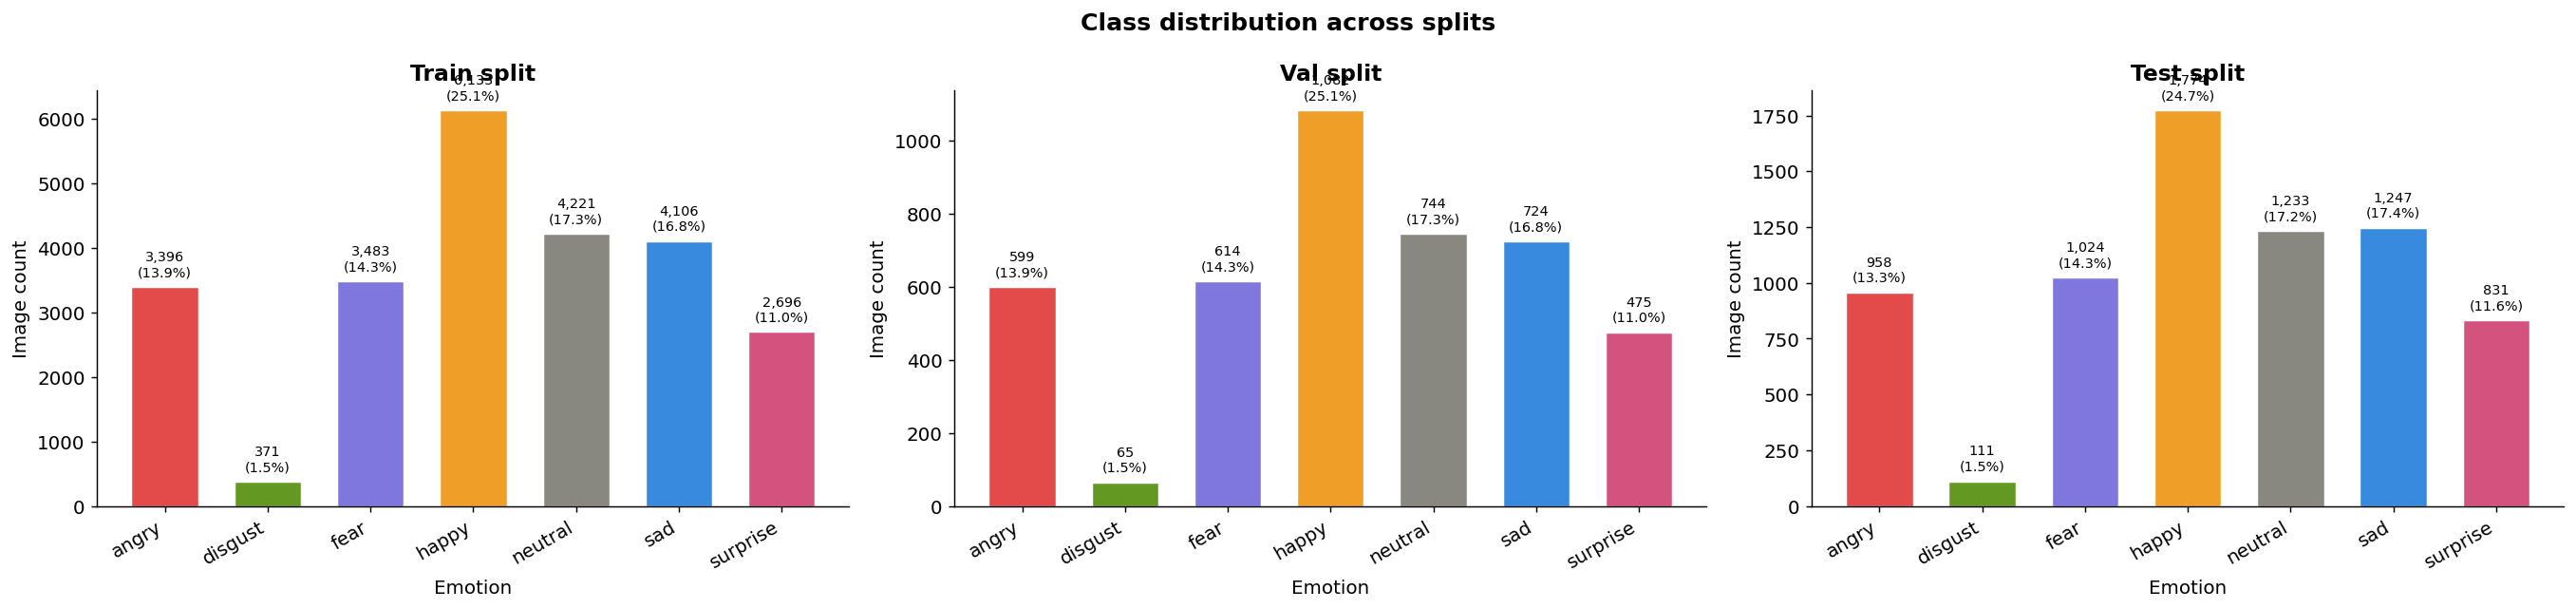

✓ Saved class_distribution.png


In [5]:
present_splits = [s for s in SPLITS if s in counts]
n_splits = len(present_splits)

fig, axes = plt.subplots(1, n_splits, figsize=(7 * n_splits, 5), sharey=False)
if n_splits == 1:
    axes = [axes]

for ax, split in zip(axes, present_splits):
    split_counts = counts[split]
    emotions = [e for e in EMOTIONS if e in split_counts]
    values   = [split_counts[e] for e in emotions]
    colors   = [PALETTE[e] for e in emotions]

    bars = ax.bar(emotions, values, color=colors, edgecolor="white",
                  linewidth=0.8, width=0.65)
    ax.set_title(f"{split.capitalize()} split", fontsize=13, fontweight="bold")
    ax.set_xlabel("Emotion")
    ax.set_ylabel("Image count")
    ax.set_xticklabels(emotions, rotation=30, ha="right")

    total = sum(values)
    for bar, v in zip(bars, values):
        pct = 100 * v / total if total else 0
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + total * 0.005,
                f"{v:,}\n({pct:.1f}%)", ha="center", va="bottom", fontsize=8)

fig.suptitle("Class distribution across splits", fontsize=14, fontweight="bold")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "class_distribution.png", bbox_inches="tight")
plt.show()
print("✓ Saved class_distribution.png")


## 6. Class Imbalance Heatmap

This section visualizes class imbalance using a heatmap that compares each emotion class against the majority class within each dataset split. The values represent the ratio of each class count relative to the largest class count in the same split. The heatmap makes minority and majority classes easier to identify visually. Green indicates classes with higher representation, while red highlights underrepresented classes such as `disgust`. This analysis is important because strong class imbalance can bias the model toward majority emotions and reduce performance on minority classes, so it motivates the use of balancing strategies in later training phases.

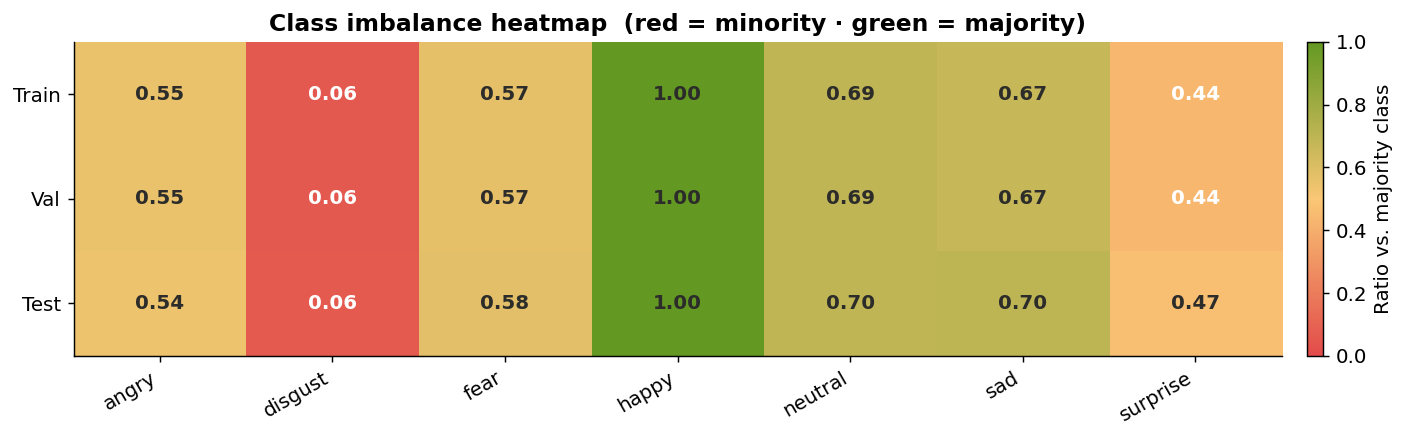

✓ Saved imbalance_heatmap.png


In [6]:
present_splits = [s for s in SPLITS if s in counts]

matrix = []
for split in present_splits:
    split_counts = counts[split]
    max_c = max(split_counts.values()) if split_counts else 1
    row = [split_counts.get(em, 0) / max_c for em in EMOTIONS]
    matrix.append(row)

matrix = np.array(matrix)

cmap = LinearSegmentedColormap.from_list(
    "imbalance", ["#E24B4A", "#FAC775", "#639922"], N=256
)

fig, ax = plt.subplots(figsize=(11, 3.5))
im = ax.imshow(matrix, cmap=cmap, vmin=0, vmax=1, aspect="auto")

ax.set_xticks(range(len(EMOTIONS)))
ax.set_xticklabels(EMOTIONS, rotation=30, ha="right", fontsize=11)
ax.set_yticks(range(len(present_splits)))
ax.set_yticklabels([s.capitalize() for s in present_splits], fontsize=11)

for i in range(len(present_splits)):
    for j in range(len(EMOTIONS)):
        v = matrix[i, j]
        color = "white" if v < 0.45 else "#2C2C2A"
        ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                fontsize=11, color=color, fontweight="bold")

plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02,
             label="Ratio vs. majority class")
ax.set_title("Class imbalance heatmap  (red = minority · green = majority)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "imbalance_heatmap.png", bbox_inches="tight")
plt.show()
print("✓ Saved imbalance_heatmap.png")


## 7. Imbalance Analysis and Training Strategy Recommendation

This section performs a detailed analysis of class imbalance by calculating the imbalance ratio (IR) for each emotion category relative to the majority class. The analysis identifies minority and majority classes and measures the severity of imbalance across different dataset splits. Based on the calculated imbalance ratios, an automatic strategy recommendation is generated to determine the most suitable training approach. Depending on the imbalance severity, techniques such as `WeightedRandomSampler`, class-weighted loss functions, and stronger augmentation for minority classes may be recommended. These recommendations help reduce model bias toward majority classes and improve performance on underrepresented emotions during training.

In [7]:
print("── Imbalance ratios (majority / each class) ─────────────────")
for split in present_splits:
    split_counts = counts[split]
    max_c  = max(split_counts.values())
    min_c  = min(split_counts.values())
    majority = max(split_counts, key=split_counts.get)
    minority = min(split_counts, key=split_counts.get)
    global_ir = max_c / min_c if min_c else float("inf")

    print(f"\n  {split.upper()}")
    print(f"  Majority class : {majority} ({max_c:,})")
    print(f"  Minority class : {minority} ({min_c:,})")
    print(f"  Global IR      : {global_ir:.2f}x")
    for em in EMOTIONS:
        c  = split_counts.get(em, 0)
        ir = max_c / c if c else float("inf")
        flag = " ← severe" if ir > 5 else (" ← moderate" if ir > 2 else "")
        print(f"    {em:<12}  IR = {ir:5.2f}x{flag}")

# Strategy recommendation
print("\n── Strategy recommendation ──────────────────────────────────")
train_counts = counts.get("train", {})
if train_counts:
    max_c = max(train_counts.values())
    min_c = min(train_counts.values())
    ir = max_c / min_c if min_c else float("inf")
    if ir > 10:
        print("  SEVERE imbalance (IR > 10x).")
        print("  → WeightedRandomSampler + class-weighted CrossEntropyLoss")
        print("  → Heavy augmentation on minority classes (disgust, fear)")
    elif ir > 3:
        print("  MODERATE imbalance (3x < IR ≤ 10x).")
        print("  → WeightedRandomSampler + class-weighted CrossEntropyLoss")
    else:
        print("  MILD imbalance (IR ≤ 3x).")
        print("  → class-weighted CrossEntropyLoss only")


── Imbalance ratios (majority / each class) ─────────────────

  TRAIN
  Majority class : happy (6,133)
  Minority class : disgust (371)
  Global IR      : 16.53x
    angry         IR =  1.81x
    disgust       IR = 16.53x ← severe
    fear          IR =  1.76x
    happy         IR =  1.00x
    neutral       IR =  1.45x
    sad           IR =  1.49x
    surprise      IR =  2.27x ← moderate

  VAL
  Majority class : happy (1,082)
  Minority class : disgust (65)
  Global IR      : 16.65x
    angry         IR =  1.81x
    disgust       IR = 16.65x ← severe
    fear          IR =  1.76x
    happy         IR =  1.00x
    neutral       IR =  1.45x
    sad           IR =  1.49x
    surprise      IR =  2.28x ← moderate

  TEST
  Majority class : happy (1,774)
  Minority class : disgust (111)
  Global IR      : 15.98x
    angry         IR =  1.85x
    disgust       IR = 15.98x ← severe
    fear          IR =  1.73x
    happy         IR =  1.00x
    neutral       IR =  1.44x
    sad           IR

## 8. Sample Image Visualization

This section displays random sample images from each available emotion class in the dataset. The visualization helps provide a visual understanding of the facial expressions, image quality, lighting variation, and pose differences present in the FER2013 dataset. By inspecting samples from each class, we can better understand why some emotions may be easier or harder for the model to distinguish. This step also helps identify possible challenges such as low-resolution images, ambiguous expressions, and visual similarity between emotion categories. The generated sample grid is saved for documentation and can be used later in the project report.

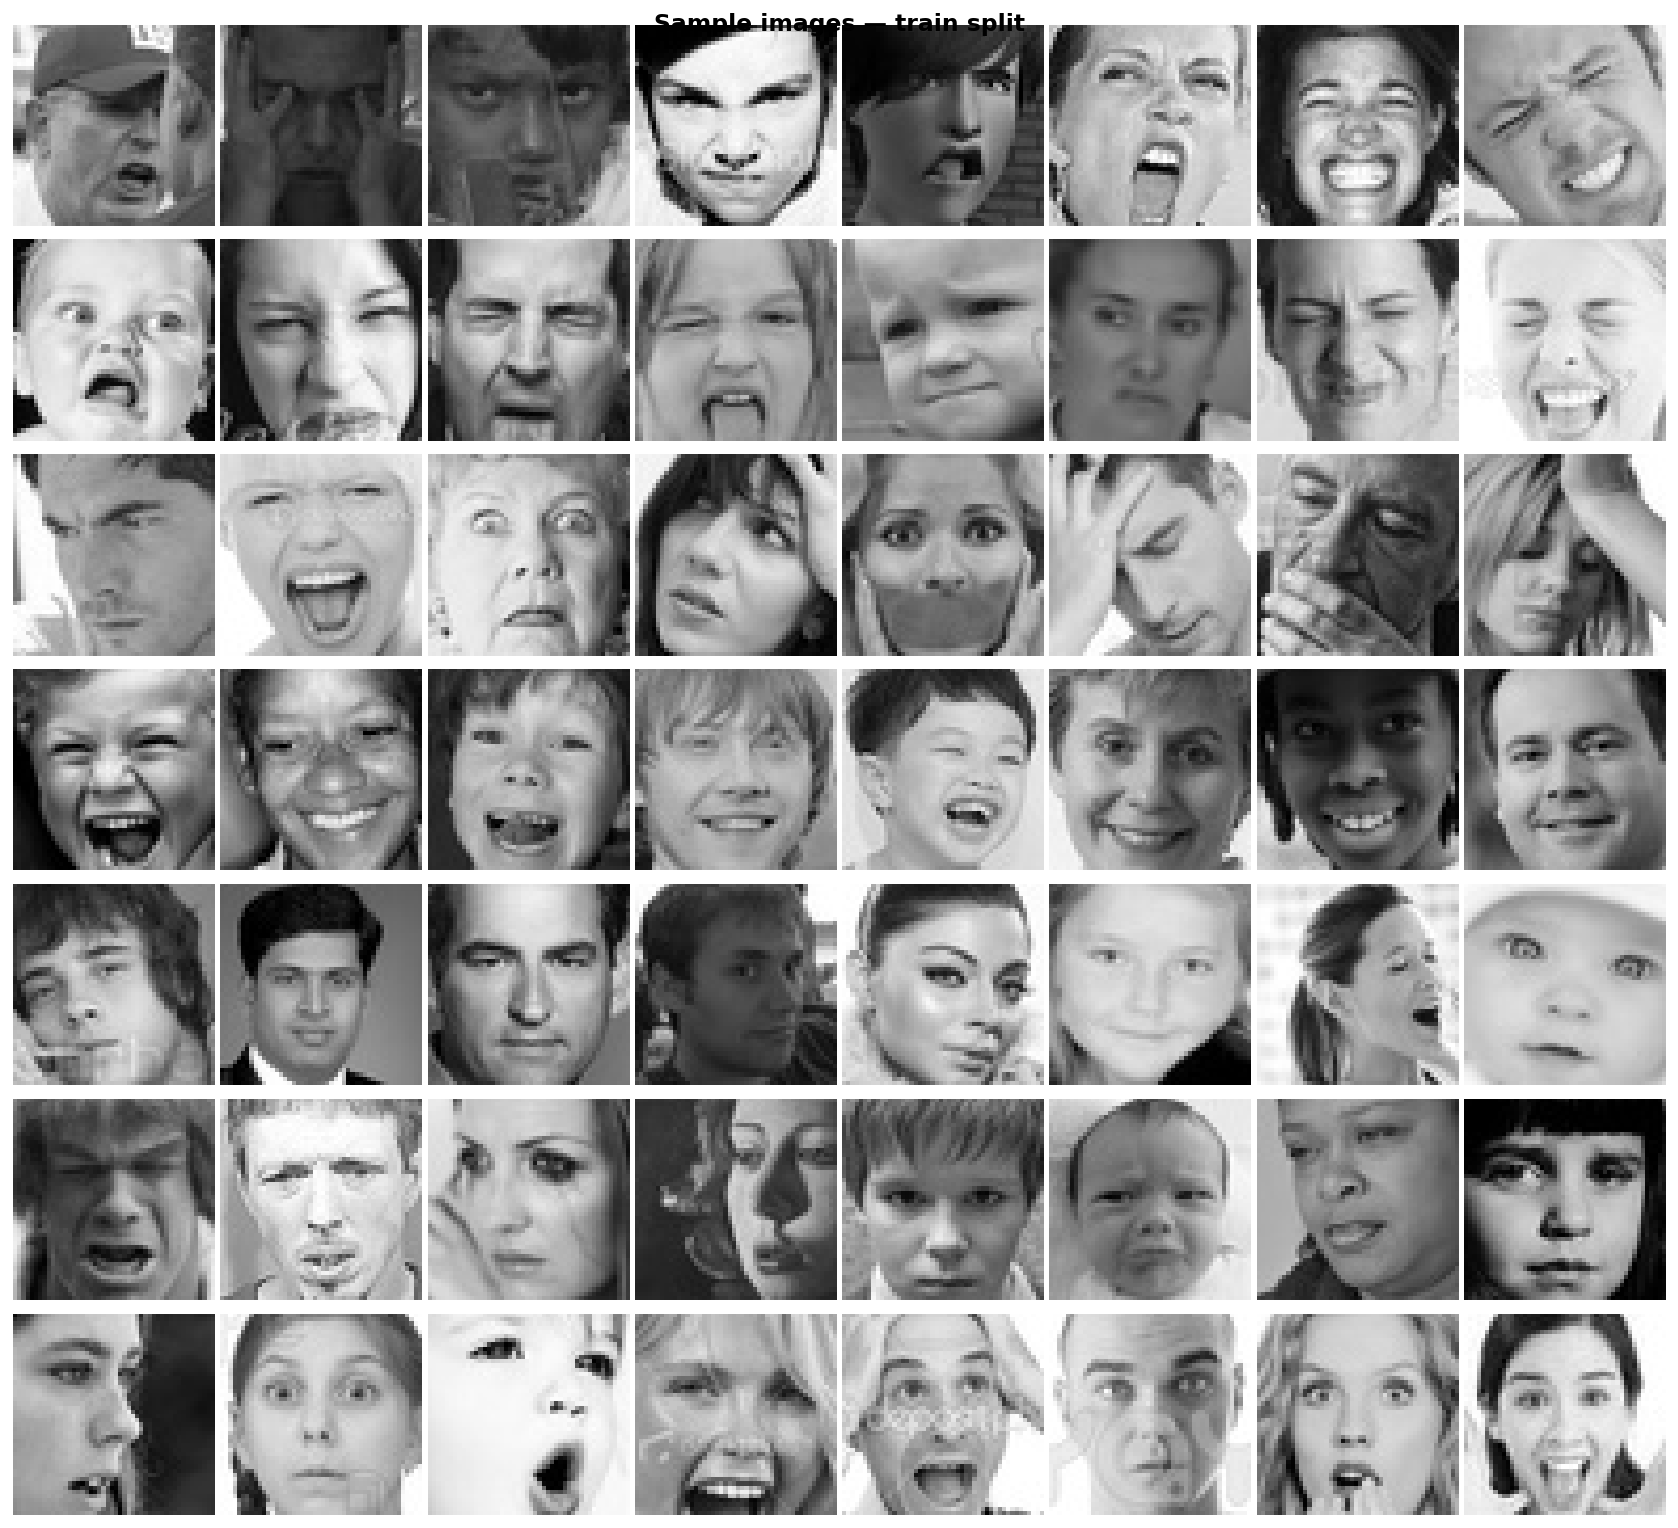

✓ Saved sample_grid.png


In [8]:
split = "train" if "train" in paths else list(paths.keys())[0]
emotions_avail = [e for e in EMOTIONS if e in paths[split] and paths[split][e]]

N_COLS = 8
N_ROWS = len(emotions_avail)

fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(N_COLS * 1.6, N_ROWS * 1.7))

for r, emotion in enumerate(emotions_avail):
    pool    = paths[split][emotion]
    samples = random.sample(pool, min(N_COLS, len(pool)))
    while len(samples) < N_COLS:
        samples.append(samples[-1])

    for c, img_path in enumerate(samples[:N_COLS]):
        ax = axes[r][c]
        ax.imshow(load_rgb(img_path))
        ax.axis("off")
        if c == 0:
            ax.set_ylabel(emotion, fontsize=10, fontweight="bold",
                          color=PALETTE[emotion], labelpad=4)

fig.suptitle(f"Sample images — {split} split", fontsize=13, fontweight="bold")
plt.tight_layout(pad=0.3)
fig.savefig(OUTPUT_DIR / "sample_grid.png", bbox_inches="tight")
plt.show()
print("✓ Saved sample_grid.png")


## 9. Pixel Statistics Analysis

This section calculates pixel-level statistics for each emotion category by sampling a subset of images from every dataset split. The mean and standard deviation values are computed to summarize the overall brightness and variation within the images. Pixel statistics provide useful information about image characteristics and help determine appropriate normalization parameters for later preprocessing stages. Understanding these values also helps identify possible differences in image intensity and contrast across emotion categories. The computed statistics will be used in the following phases to ensure consistent image normalization during model training and inference.

In [9]:
pixel_stats = defaultdict(dict)

for split in present_splits:
    for emotion in tqdm(EMOTIONS, desc=f"{split} split"):
        if emotion not in paths[split] or not paths[split][emotion]:
            continue
        pool   = paths[split][emotion]
        sample = random.sample(pool, min(PIXEL_SAMPLE, len(pool)))
        means, stds = [], []
        for p in sample:
            arr = load_rgb(p).astype(np.float32) / 255.0
            means.append(arr.mean())
            stds.append(arr.std())
        pixel_stats[split][emotion] = {
            "mean": float(np.mean(means)),
            "std":  float(np.mean(stds)),
        }

print("\n── Pixel stats summary ──────────────────────────────────────")
for split in present_splits:
    print(f"\n  {split.upper()}")
    for em in EMOTIONS:
        if em not in pixel_stats[split]:
            continue
        m = pixel_stats[split][em]["mean"]
        s = pixel_stats[split][em]["std"]
        print(f"    {em:<12}  mean={m:.4f}  std={s:.4f}")


train split:   0%|          | 0/7 [00:00<?, ?it/s]

val split:   0%|          | 0/7 [00:00<?, ?it/s]

test split:   0%|          | 0/7 [00:00<?, ?it/s]


── Pixel stats summary ──────────────────────────────────────

  TRAIN
    angry         mean=0.4953  std=0.2100
    disgust       mean=0.5337  std=0.2043
    fear          mean=0.5301  std=0.2118
    happy         mean=0.5021  std=0.2063
    neutral       mean=0.4848  std=0.2096
    sad           mean=0.4747  std=0.2155
    surprise      mean=0.5654  std=0.2171

  VAL
    angry         mean=0.4963  std=0.2114
    disgust       mean=0.4988  std=0.2086
    fear          mean=0.5448  std=0.2148
    happy         mean=0.5125  std=0.2091
    neutral       mean=0.4806  std=0.2131
    sad           mean=0.4689  std=0.2105
    surprise      mean=0.5749  std=0.2145

  TEST
    angry         mean=0.5096  std=0.2194
    disgust       mean=0.5280  std=0.1969
    fear          mean=0.5356  std=0.2209
    happy         mean=0.4983  std=0.2090
    neutral       mean=0.4868  std=0.2083
    sad           mean=0.4833  std=0.2079
    surprise      mean=0.5732  std=0.2158


## 10. Pixel Statistics Visualization

This section visualizes the calculated pixel statistics for each emotion class across the available dataset splits. The first chart shows the mean pixel brightness, while the second chart shows the pixel standard deviation for each emotion. These plots help compare brightness and contrast patterns between emotion classes and dataset splits. Consistent pixel statistics indicate that the dataset has relatively stable image intensity characteristics, while visible differences may suggest the need for careful normalization. The generated figure is saved for documentation and supports the preprocessing decisions used in the next phase.

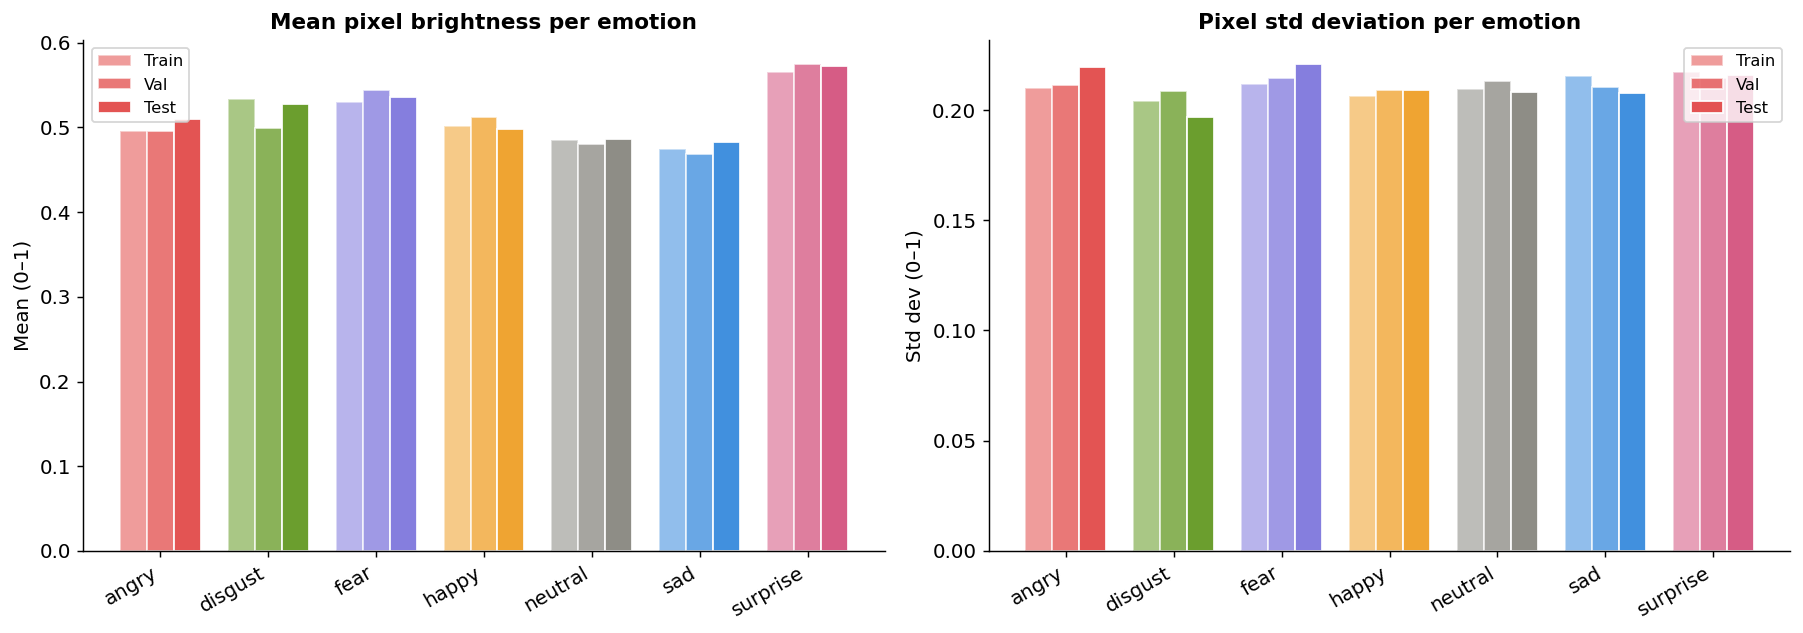

✓ Saved pixel_stats.png


In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

x     = np.arange(len(EMOTIONS))
width = 0.25

for i, split in enumerate(present_splits):
    means  = [pixel_stats[split].get(em, {}).get("mean", 0) for em in EMOTIONS]
    stds   = [pixel_stats[split].get(em, {}).get("std",  0) for em in EMOTIONS]
    offset = (i - len(present_splits) / 2 + 0.5) * width
    colors = [PALETTE[e] for e in EMOTIONS]

    ax1.bar(x + offset, means, width, label=split.capitalize(),
            color=colors, alpha=0.55 + 0.2 * i, edgecolor="white")
    ax2.bar(x + offset, stds,  width, label=split.capitalize(),
            color=colors, alpha=0.55 + 0.2 * i, edgecolor="white")

for ax, title, ylabel in [
    (ax1, "Mean pixel brightness per emotion", "Mean (0–1)"),
    (ax2, "Pixel std deviation per emotion",   "Std dev (0–1)"),
]:
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(EMOTIONS, rotation=30, ha="right")
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=9)

plt.tight_layout()
fig.savefig(OUTPUT_DIR / "pixel_stats.png", bbox_inches="tight")
plt.show()
print("✓ Saved pixel_stats.png")


## 11. Dataset Normalization Parameters

This section computes the global dataset normalization values by calculating weighted average pixel statistics based on class frequencies in the training set. The final dataset mean and standard deviation values are derived from the previously calculated emotion-level statistics. These values are intended to be used in the `transforms.Normalize()` step during preprocessing to ensure that image inputs have a consistent scale during training and inference. Because the FER2013 dataset consists of grayscale images converted to RGB format, the three channels have nearly identical statistics. Using dataset-specific normalization values is preferred over default ImageNet normalization because it better represents the characteristics of the facial emotion dataset.

In [11]:
# Weighted average across emotions by class count
train_counts = counts.get("train", counts.get(list(counts.keys())[0], {}))
total_train  = sum(train_counts.get(em, 0) for em in EMOTIONS)

global_mean = 0.0
global_std  = 0.0
for em in EMOTIONS:
    w = train_counts.get(em, 0) / total_train if total_train else 0
    global_mean += w * pixel_stats.get("train", pixel_stats.get(list(pixel_stats.keys())[0], {})).get(em, {}).get("mean", 0)
    global_std  += w * pixel_stats.get("train", pixel_stats.get(list(pixel_stats.keys())[0], {})).get(em, {}).get("std",  0)

print("── Copy these into your Phase 2 transforms.Normalize() ─────")
print(f"   DATASET_MEAN = [{global_mean:.4f}, {global_mean:.4f}, {global_mean:.4f}]")
print(f"   DATASET_STD  = [{global_std:.4f},  {global_std:.4f},  {global_std:.4f}]")
print()
print("  (RGB channels are nearly identical since FER2013 was grayscale-to-RGB.)")
print("  (These are dataset-specific values; ImageNet defaults differ.)")


── Copy these into your Phase 2 transforms.Normalize() ─────
   DATASET_MEAN = [0.5050, 0.5050, 0.5050]
   DATASET_STD  = [0.2109,  0.2109,  0.2109]

  (RGB channels are nearly identical since FER2013 was grayscale-to-RGB.)
  (These are dataset-specific values; ImageNet defaults differ.)


## 12. Image Size Distribution Analysis

This section analyzes the distribution of image dimensions across emotion classes by sampling images from the training split. The height and width of each image are extracted and visualized using a scatter plot. The visualization helps determine whether image sizes are consistent throughout the dataset or whether resizing is required before training. Consistent image dimensions simplify preprocessing and model input preparation, while large variations may require additional resizing operations. The generated plot also provides useful insight for selecting an appropriate input size during the preprocessing and model training stages.

Sampling sizes:   0%|          | 0/7 [00:00<?, ?it/s]

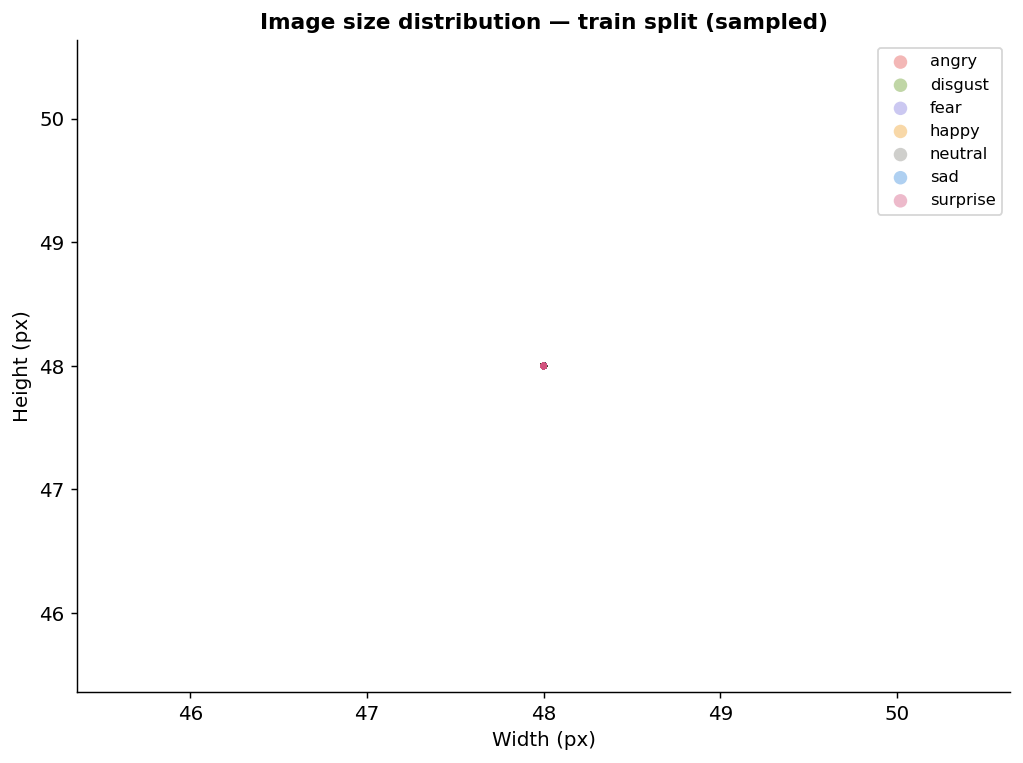

✓ Saved image_size_dist.png


In [12]:
split = "train" if "train" in paths else list(paths.keys())[0]
size_data = {}

for emotion in tqdm(EMOTIONS, desc="Sampling sizes"):
    if emotion not in paths[split] or not paths[split][emotion]:
        continue
    pool   = paths[split][emotion]
    sample = random.sample(pool, min(SIZE_SAMPLE, len(pool)))
    sizes  = []
    for p in sample:
        with Image.open(p) as img:
            w, h = img.size
            sizes.append((h, w))
    size_data[emotion] = sizes

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
for emotion, sizes in size_data.items():
    hs = [s[0] for s in sizes]
    ws = [s[1] for s in sizes]
    ax.scatter(ws, hs, label=emotion, alpha=0.4, s=14,
               color=PALETTE[emotion], edgecolors="none")

ax.set_xlabel("Width (px)")
ax.set_ylabel("Height (px)")
ax.set_title(f"Image size distribution — {split} split (sampled)",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=9, markerscale=2)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "image_size_dist.png", bbox_inches="tight")
plt.show()
print("✓ Saved image_size_dist.png")


## 13. Image Size Summary

This section summarizes the sampled image dimensions by reporting the minimum, maximum, and average height and width values. It also checks how many unique image size pairs exist in the dataset. If all images have the same dimensions, the dataset is considered uniformly sized. If mixed sizes are detected, resizing becomes necessary in the preprocessing pipeline. This step supports the Phase 2 preprocessing decision by confirming whether `transforms.Resize()` is required before feeding images into the model.

In [13]:
all_sizes = [s for sizes in size_data.values() for s in sizes]
hs = [s[0] for s in all_sizes]
ws = [s[1] for s in all_sizes]
unique = set(all_sizes)

print("── Image size summary ───────────────────────────────────────")
print(f"  Height : min={min(hs)}  max={max(hs)}  mean={np.mean(hs):.1f}")
print(f"  Width  : min={min(ws)}  max={max(ws)}  mean={np.mean(ws):.1f}")
print(f"  Unique (H, W) pairs found: {len(unique)}")

if len(unique) == 1:
    h0, w0 = list(unique)[0]
    print(f"  All images are {w0}×{h0} — uniformly sized.")
    print(f"  Recommended model input: 224×224 (resize up + normalize).")
else:
    print("  Mixed sizes detected!")
    print("  Phase 2 DataLoader must include transforms.Resize((224, 224)).")


── Image size summary ───────────────────────────────────────
  Height : min=48  max=48  mean=48.0
  Width  : min=48  max=48  mean=48.0
  Unique (H, W) pairs found: 1
  All images are 48×48 — uniformly sized.
  Recommended model input: 224×224 (resize up + normalize).


## 14. EDA Summary Report Generation

This final section generates a complete summary report of the EDA findings and saves it as a text file for future reference. The report combines the main observations collected throughout the analysis process, including class distributions, imbalance information, normalization parameters, image size statistics, and preprocessing recommendations. In addition, a Phase 2 preparation checklist is automatically created to outline the required components for the next stage of the project, such as dataset classes, augmentation methods, normalization settings, and data loaders.Generating a structured report improves reproducibility and provides a concise summary of the most important dataset insights for later project stages and documentation.

In [14]:
lines = []
lines.append("=" * 62)
lines.append("  PHASE 1 — EDA REPORT")
lines.append("=" * 62)

lines.append("\n── Class counts ─────────────────────────────────────────────")
for split in SPLITS:
    if split not in counts:
        continue
    lines.append(f"\n  {split.upper()} split:")
    split_counts = counts[split]
    total    = sum(split_counts.values())
    majority = max(split_counts, key=split_counts.get)
    minority = min(split_counts, key=split_counts.get)
    for em in EMOTIONS:
        c   = split_counts.get(em, 0)
        pct = 100 * c / total if total else 0
        lines.append(f"    {em:<12} {c:>7,}   ({pct:5.1f}%)")
    lines.append(f"    {'TOTAL':<12} {total:>7,}")
    ir = split_counts[majority] / split_counts[minority] if split_counts.get(minority) else float("inf")
    lines.append(f"    Majority  : {majority}  ({split_counts[majority]:,})")
    lines.append(f"    Minority  : {minority}  ({split_counts[minority]:,})")
    lines.append(f"    Global IR : {ir:.2f}x")

lines.append("\n── Normalization constants (for Phase 2) ─────────────────────")
lines.append(f"    DATASET_MEAN = [{global_mean:.4f}, {global_mean:.4f}, {global_mean:.4f}]")
lines.append(f"    DATASET_STD  = [{global_std:.4f},  {global_std:.4f},  {global_std:.4f}]")

lines.append("\n── Image size summary ────────────────────────────────────────")
lines.append(f"    Height : min={min(hs)}  max={max(hs)}  mean={np.mean(hs):.1f}")
lines.append(f"    Width  : min={min(ws)}  max={max(ws)}  mean={np.mean(ws):.1f}")
lines.append(f"    Unique (H, W) pairs : {len(unique)}")

lines.append("\n── Phase 2 checklist ─────────────────────────────────────────")
lines.append("    [ ] FERDataset class with __len__ and __getitem__")
lines.append("    [ ] WeightedRandomSampler weights from train counts")
lines.append("    [ ] Augmentation pipeline (flip, jitter, erasing, MixUp)")
lines.append("    [ ] transforms.Normalize with values above")
lines.append("    [ ] DataLoaders: train / val / test")
lines.append("    [ ] class_weights tensor for CrossEntropyLoss")
lines.append("\n" + "=" * 62)

report_text = "\n".join(lines)
print(report_text)

report_path = OUTPUT_DIR / "eda_report.txt"
with open(report_path, "w") as f:
    f.write(report_text)
print(f"\n✓ Saved eda_report.txt")


  PHASE 1 — EDA REPORT

── Class counts ─────────────────────────────────────────────

  TRAIN split:
    angry          3,396   ( 13.9%)
    disgust          371   (  1.5%)
    fear           3,483   ( 14.3%)
    happy          6,133   ( 25.1%)
    neutral        4,221   ( 17.3%)
    sad            4,106   ( 16.8%)
    surprise       2,696   ( 11.0%)
    TOTAL         24,406
    Majority  : happy  (6,133)
    Minority  : disgust  (371)
    Global IR : 16.53x

  VAL split:
    angry            599   ( 13.9%)
    disgust           65   (  1.5%)
    fear             614   ( 14.3%)
    happy          1,082   ( 25.1%)
    neutral          744   ( 17.3%)
    sad              724   ( 16.8%)
    surprise         475   ( 11.0%)
    TOTAL          4,303
    Majority  : happy  (1,082)
    Minority  : disgust  (65)
    Global IR : 16.65x

  TEST split:
    angry            958   ( 13.3%)
    disgust          111   (  1.5%)
    fear           1,024   ( 14.3%)
    happy          1,774   ( 24.7%)
  